# Moirai Post-Training Evaluation & Visualization Notebook
Configure your model path and datasets below, then run all cells.

### Imports

In [1]:
import os
import csv
import json
import logging
import warnings
from itertools import islice
from typing import Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dotenv import load_dotenv

from gluonts.itertools import batcher
from gluonts.model.forecast import QuantileForecast
from gluonts.model import evaluate_model
from gluonts.time_feature import get_seasonality
from gluonts.ev.metrics import (
    MSE, MAE, MASE, MAPE, SMAPE, MSIS, RMSE, NRMSE, ND,
    MeanWeightedSumQuantileLoss,
)

from gift_eval.data import Dataset
from uni2ts.model.moiraic import MoiraicForecast, MoiraicModule

load_dotenv()
logging.getLogger("gluonts.model.forecast").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.facecolor": "white",
})

print("Imports complete.")

Imports complete.


## Configuration

In [2]:
# ============================================================
# CONFIGURATION — Edit this cell to change what gets evaluated
# ============================================================

# --- Model ---
MODEL_NAME = "moiraie_base"
# Supported: "hf" for HuggingFace-style saved checkpoints, "ckpt" for Lightning .ckpt files
CHECKPOINT_TYPE = "hf"
MODEL_PATH = "/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_4/HF_checkpoints/last"

# --- Inference ---
CONTEXT_LENGTH = 4000
BATCH_SIZE = 512
QUANTILE_LEVELS = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
DEVICE = "cuda:4"  # "auto", "cuda", "cpu"

# --- Datasets ---
# Space-separated dataset names. Comment/uncomment or edit freely.
SHORT_DATASETS = "electricity/H"
# SHORT_DATASETS = "m4_yearly m4_quarterly m4_monthly m4_weekly m4_daily m4_hourly electricity/15T electricity/H electricity/D electricity/W solar/10T solar/H solar/D solar/W hospital covid_deaths us_births/D us_births/M us_births/W saugeenday/D saugeenday/M saugeenday/W temperature_rain_with_missing kdd_cup_2018_with_missing/H kdd_cup_2018_with_missing/D car_parts_with_missing restaurant hierarchical_sales/D hierarchical_sales/W LOOP_SEATTLE/5T LOOP_SEATTLE/H LOOP_SEATTLE/D SZ_TAXI/15T SZ_TAXI/H M_DENSE/H M_DENSE/D ett1/15T ett1/H ett1/D ett1/W ett2/15T ett2/H ett2/D ett2/W jena_weather/10T jena_weather/H jena_weather/D bitbrains_fast_storage/5T bitbrains_fast_storage/H bitbrains_rnd/5T bitbrains_rnd/H bizitobs_application bizitobs_service bizitobs_l2c/5T bizitobs_l2c/H"

MED_LONG_DATASETS = "bizitobs_l2c/H"
# MED_LONG_DATASETS = "electricity/15T electricity/H solar/10T solar/H kdd_cup_2018_with_missing/H LOOP_SEATTLE/5T LOOP_SEATTLE/H SZ_TAXI/15T M_DENSE/H ett1/15T ett1/H ett2/15T ett2/H jena_weather/10T jena_weather/H bitbrains_fast_storage/5T bitbrains_rnd/5T bizitobs_application bizitobs_service bizitobs_l2c/5T bizitobs_l2c/H"

# --- Output ---
OUTPUT_DIR = "../results/moiraie_base"

# --- Visualization ---
NUM_SERIES_TO_PLOT = 6          # How many individual series to plot per dataset/term
CONTEXT_POINTS_TO_SHOW = 200    # How many historical points to display before the forecast
VIZ_SEED = 42                   # For reproducible random series selection

# Pretty name mapping (dataset key -> display name)
PRETTY_NAMES = {
    "saugeenday": "saugeen",
    "temperature_rain_with_missing": "temperature_rain",
    "kdd_cup_2018_with_missing": "kdd_cup_2018",
    "car_parts_with_missing": "car_parts",
}

## Setup

In [3]:
def get_device(device="auto"):
    if device == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device)

def load_module(model_path: str, checkpoint_type: str = "hf"):
    """
    Load the MoiraicModule from either a HuggingFace checkpoint directory
    or a raw Lightning .ckpt file.
    """
    if checkpoint_type == "hf":
        module = MoiraicModule.from_pretrained(model_path)
    elif checkpoint_type == "ckpt":
        # --- Lightning checkpoint loading ---
        # You may need to pass additional hparams depending on your config.
        # Adjust the call below to match your training setup.
        module = MoiraicModule.load_from_checkpoint(model_path)
    else:
        raise ValueError(f"Unknown checkpoint_type: {checkpoint_type!r}. Use 'hf' or 'ckpt'.")
    print(f"Loaded module from {model_path} (type={checkpoint_type})")
    return module

device = get_device(DEVICE)
module = load_module(MODEL_PATH, CHECKPOINT_TYPE)
print(f"Using device: {device}")

Loading weights from local directory
Loaded module from /srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_4/HF_checkpoints/last (type=hf)
Using device: cuda:4


In [4]:
class MoiraiQuantilePredictor:
    """
    Wraps MoiraicForecast for quantile prediction.
    Accepts a pre-loaded module so it isn't reloaded per dataset.
    """
    def __init__(
        self,
        module: MoiraicModule,
        prediction_length: int,
        context_length: int = 4000,
        target_dim: int = 1,
        feat_dynamic_real_dim: int = 0,
        past_feat_dynamic_real_dim: int = 0,
        device: torch.device = torch.device("cpu"),
        batch_size: int = 512,
        quantile_levels: tuple = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
    ):
        self.prediction_length = prediction_length
        self.context_length = context_length
        self.device = device
        self.batch_size = batch_size
        self.quantile_levels = quantile_levels

        self.model = MoiraicForecast(
            module=module,
            prediction_length=prediction_length,
            context_length=context_length,
            target_dim=target_dim,
            feat_dynamic_real_dim=feat_dynamic_real_dim,
            past_feat_dynamic_real_dim=past_feat_dynamic_real_dim,
        ).to(self.device)

    def predict(self, test_data_input):
        batch_size = self.batch_size
        while True:
            try:
                forecast_quantiles = []
                for batch in batcher(test_data_input, batch_size=batch_size):
                    past_target = [entry["target"] for entry in batch]
                    forecasts = self.model.predict(past_target)
                    forecast_quantiles.append(forecasts)
                forecast_quantiles = np.concatenate(forecast_quantiles)
                break
            except torch.cuda.OutOfMemoryError:
                batch_size //= 2
                if batch_size < 1:
                    raise
                print(f"OOM — reducing batch_size to {batch_size}")

        quantile_forecasts = []
        for item, ts in zip(forecast_quantiles, test_data_input):
            forecast_start_date = ts["start"] + len(ts["target"])
            quantile_forecasts.append(
                QuantileForecast(
                    item_id=ts["item_id"],
                    forecast_arrays=item,
                    start_date=forecast_start_date,
                    forecast_keys=list(map(str, self.quantile_levels)),
                )
            )
        return quantile_forecasts

print("Predictor class defined.")

Predictor class defined.


In [5]:
metrics = [
    MSE(forecast_type="mean"),
    MSE(forecast_type=0.5),
    MAE(),
    MASE(),
    MAPE(),
    SMAPE(),
    MSIS(),
    RMSE(),
    NRMSE(),
    ND(),
    MeanWeightedSumQuantileLoss(quantile_levels=list(QUANTILE_LEVELS)),
]

METRIC_COLUMNS = [
    "eval_metrics/MSE[mean]",
    "eval_metrics/MSE[0.5]",
    "eval_metrics/MAE[0.5]",
    "eval_metrics/MASE[0.5]",
    "eval_metrics/MAPE[0.5]",
    "eval_metrics/sMAPE[0.5]",
    "eval_metrics/MSIS",
    "eval_metrics/RMSE[mean]",
    "eval_metrics/NRMSE[mean]",
    "eval_metrics/ND[0.5]",
    "eval_metrics/mean_weighted_sum_quantile_loss",
]

METRIC_KEYS = [
    "MSE[mean]", "MSE[0.5]", "MAE[0.5]", "MASE[0.5]", "MAPE[0.5]",
    "sMAPE[0.5]", "MSIS", "RMSE[mean]", "NRMSE[mean]", "ND[0.5]",
    "mean_weighted_sum_quantile_loss",
]

dataset_properties_map = json.load(open("/srv/disk00/ctadler/gift-eval/notebooks/dataset_properties.json"))

all_datasets = list(set(SHORT_DATASETS.split() + MED_LONG_DATASETS.split()))

def resolve_ds_config(ds_name, term):
    """Return (ds_key, ds_freq, ds_config) for a dataset name and term."""
    if "/" in ds_name:
        ds_key, ds_freq = ds_name.split("/", 1)
        ds_key = ds_key.lower()
        ds_key = PRETTY_NAMES.get(ds_key, ds_key)
    else:
        ds_key = ds_name.lower()
        ds_key = PRETTY_NAMES.get(ds_key, ds_key)
        ds_freq = dataset_properties_map[ds_key]["frequency"]
    ds_config = f"{ds_key}/{ds_freq}/{term}"
    return ds_key, ds_freq, ds_config

print(f"Will evaluate on {len(all_datasets)} dataset(s): {all_datasets}")

Will evaluate on 2 dataset(s): ['bizitobs_l2c/H', 'electricity/H']


## Run Eval

In [6]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
csv_file_path = os.path.join(OUTPUT_DIR, "all_results.csv")

# Write CSV header
with open(csv_file_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["dataset", "model"] + METRIC_COLUMNS + ["domain", "num_variates"])

for ds_name in all_datasets:
    terms = ["short", "medium", "long"]
    for term in terms:
        if term in ("medium", "long") and ds_name not in MED_LONG_DATASETS.split():
            continue

        ds_key, ds_freq, ds_config = resolve_ds_config(ds_name, term)
        print(f"\n{'='*60}\nEvaluating: {ds_config}\n{'='*60}")

        to_univariate = Dataset(name=ds_name, term=term, to_univariate=False).target_dim != 1
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)

        predictor = MoiraiQuantilePredictor(
            module=module,
            prediction_length=dataset.prediction_length,
            context_length=CONTEXT_LENGTH,
            target_dim=1,
            past_feat_dynamic_real_dim=dataset.past_feat_dynamic_real_dim,
            device=device,
            batch_size=BATCH_SIZE,
            quantile_levels=QUANTILE_LEVELS,
        )

        season_length = get_seasonality(dataset.freq)

        res = evaluate_model(
            predictor,
            test_data=dataset.test_data,
            metrics=metrics,
            batch_size=BATCH_SIZE,
            axis=None,
            mask_invalid_label=True,
            allow_nan_forecast=False,
            seasonality=season_length,
        )

        row = [ds_config, MODEL_NAME]
        row += [res[k][0] for k in METRIC_KEYS]
        row += [
            dataset_properties_map[ds_key]["domain"],
            dataset_properties_map[ds_key]["num_variates"],
        ]

        with open(csv_file_path, "a", newline="") as f:
            csv.writer(f).writerow(row)

        print(f"  ✓ Written results for {ds_config}")

print(f"\n✅ All results saved to {csv_file_path}")


Evaluating: bizitobs_l2c/H/short


42it [00:00, 682.25it/s]


  ✓ Written results for bizitobs_l2c/H/short

Evaluating: bizitobs_l2c/H/medium


7it [00:00, 455.02it/s]


  ✓ Written results for bizitobs_l2c/H/medium

Evaluating: bizitobs_l2c/H/long


7it [00:00, 459.52it/s]


  ✓ Written results for bizitobs_l2c/H/long

Evaluating: electricity/H/short
OOM — reducing batch_size to 256
OOM — reducing batch_size to 128


7400it [00:45, 163.30it/s]

  ✓ Written results for electricity/H/short

✅ All results saved to ../results/moiraie_base/all_results.csv


In [7]:
df_results = pd.read_csv(csv_file_path)

# Round numeric columns for readability
numeric_cols = df_results.select_dtypes(include="number").columns
df_results[numeric_cols] = df_results[numeric_cols].round(4)

display(df_results)

,dataset,model,eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss,domain,num_variates
0,bizitobs_l2c/H/short,moiraie_base,2.744830e+02,2.744830e+02,12.4090,1.1893,1.3904,0.9301,6.9612,16.5675,0.8930,0.6689,0.5128,Web/CloudOps,7
1,bizitobs_l2c/H/medium,moiraie_base,2.630267e+02,2.630267e+02,12.3637,1.2149,1.5877,0.9724,7.0624,16.2181,0.9820,0.7486,0.5727,Web/CloudOps,7
2,bizitobs_l2c/H/long,moiraie_base,3.052605e+02,3.052605e+02,13.3477,1.3539,1.7711,1.0128,7.6548,17.4717,1.0672,0.8153,0.6214,Web/CloudOps,7
3,electricity/H/short,moiraie_base,3.984413e+07,3.984413e+07,956.2945,4.6789,0.8783,0.4804,81.7267,6312.2209,2.9798,0.4514,0.3863,Energy,1


## Forecast Visualizations
The cells below generate qualitative plots of the model's forecasts overlaid on ground truth. Each plot shows:
- **Gray**: historical context window  
- **Blue line**: median (0.5 quantile) forecast  
- **Blue bands**: prediction intervals (10–90%, 20–80%, 30–70%, 40–60%)  
- **Red dashed**: ground truth future values

In [8]:
# Quantile band pairs (outer to inner) for the fan chart
QUANTILE_PAIRS = [(0.1, 0.9), (0.2, 0.8), (0.3, 0.7), (0.4, 0.6)]
BAND_ALPHAS =    [0.15,       0.25,        0.35,        0.45]

def plot_forecast(
    ax,
    context: np.ndarray,
    ground_truth: np.ndarray,
    forecast: QuantileForecast,
    title: str = "",
    context_points: int = 200,
):
    """
    Plot a single time series forecast on the given axes.
    
    Parameters
    ----------
    context : 1-D array of historical values
    ground_truth : 1-D array of actual future values
    forecast : QuantileForecast object
    """
    # Trim context to last N points
    ctx = context[-context_points:]
    pred_len = len(ground_truth)
    
    # X-axis ranges
    x_ctx = np.arange(-len(ctx), 0)
    x_fct = np.arange(0, pred_len)
    
    # Plot context
    ax.plot(x_ctx, ctx, color="#4a4a4a", linewidth=0.8, label="Context")
    
    # Plot ground truth
    ax.plot(x_fct, ground_truth[:pred_len], color="#d62728", linewidth=1.0,
            linestyle="--", label="Ground Truth", alpha=0.85)
    
    # Plot quantile bands (fan chart)
    for (q_lo, q_hi), alpha in zip(QUANTILE_PAIRS, BAND_ALPHAS):
        lo = forecast.quantile(q_lo)[:pred_len]
        hi = forecast.quantile(q_hi)[:pred_len]
        ax.fill_between(x_fct, lo, hi, color="#1f77b4", alpha=alpha,
                        label=f"{int(q_lo*100)}–{int(q_hi*100)}%" if q_lo == 0.1 else None)
    
    # Plot median
    median = forecast.quantile(0.5)[:pred_len]
    ax.plot(x_fct, median, color="#1f77b4", linewidth=1.2, label="Median Forecast")
    
    # Vertical line at forecast start
    ax.axvline(x=0, color="gray", linestyle=":", linewidth=0.7, alpha=0.6)
    
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value")


def plot_forecast_grid(
    contexts, ground_truths, forecasts, dataset_label,
    context_points=200, max_plots=6,
):
    """
    Plot a grid of forecast fan charts for a dataset.
    """
    n = min(len(forecasts), max_plots)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.2 * rows),
                             squeeze=False, constrained_layout=True)
    fig.suptitle(f"Forecast Visualization — {dataset_label}", fontsize=13, fontweight="bold")
    
    for i in range(n):
        r, c = divmod(i, cols)
        item_id = forecasts[i].item_id if forecasts[i].item_id else f"series_{i}"
        plot_forecast(
            axes[r][c],
            contexts[i],
            ground_truths[i],
            forecasts[i],
            title=f"Series: {item_id}",
            context_points=context_points,
        )
    
    # Add a single legend from the first subplot
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5,
              bbox_to_anchor=(0.5, -0.02), frameon=True, fontsize=8)
    
    # Hide unused subplots
    for i in range(n, rows * cols):
        r, c = divmod(i, cols)
        axes[r][c].set_visible(False)
    
    plt.show()


def compute_calibration(ground_truths, forecasts, quantile_levels):
    """
    Compute empirical coverage for each quantile level.
    Returns (quantile_levels, observed_proportions).
    """
    observed = {q: [] for q in quantile_levels}
    for gt, fc in zip(ground_truths, forecasts):
        pred_len = min(len(gt), fc.forecast_array.shape[-1])
        for q in quantile_levels:
            q_vals = fc.quantile(q)[:pred_len]
            observed[q].append(np.mean(gt[:pred_len] <= q_vals))
    
    obs_proportions = [np.mean(observed[q]) for q in quantile_levels]
    return list(quantile_levels), obs_proportions


def plot_calibration(quantile_levels, obs_proportions, dataset_label):
    """Plot a quantile calibration diagram."""
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect Calibration")
    ax.plot(quantile_levels, obs_proportions, "o-", color="#1f77b4",
            markersize=6, linewidth=1.5, label="Observed")
    ax.fill_between(quantile_levels, obs_proportions,
                    quantile_levels, alpha=0.15, color="#1f77b4")
    ax.set_xlabel("Predicted Quantile Level")
    ax.set_ylabel("Observed Proportion Below Quantile")
    ax.set_title(f"Quantile Calibration — {dataset_label}", fontsize=11)
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_error_distribution(ground_truths, forecasts, dataset_label):
    """Plot histogram of median forecast errors."""
    errors = []
    for gt, fc in zip(ground_truths, forecasts):
        pred_len = min(len(gt), fc.forecast_array.shape[-1])
        median = fc.quantile(0.5)[:pred_len]
        errors.extend((gt[:pred_len] - median).tolist())
    
    errors = np.array(errors)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # Histogram
    axes[0].hist(errors, bins=60, color="#1f77b4", alpha=0.7, edgecolor="white", linewidth=0.3)
    axes[0].axvline(0, color="red", linestyle="--", linewidth=0.8)
    axes[0].set_title("Forecast Error Distribution (Actual − Median)")
    axes[0].set_xlabel("Error")
    axes[0].set_ylabel("Count")
    
    # QQ-style: sorted errors vs expected
    sorted_err = np.sort(errors)
    expected = np.linspace(sorted_err[0], sorted_err[-1], len(sorted_err))
    axes[1].scatter(expected, sorted_err, s=1, alpha=0.4, color="#1f77b4")
    axes[1].plot([sorted_err[0], sorted_err[-1]], [sorted_err[0], sorted_err[-1]],
                 "r--", linewidth=0.8)
    axes[1].set_title("QQ Plot of Errors")
    axes[1].set_xlabel("Expected")
    axes[1].set_ylabel("Observed")
    
    fig.suptitle(f"Error Analysis — {dataset_label}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("Visualization functions defined.")

Visualization functions defined.



🔍 Visualizing: bizitobs_l2c/H/short


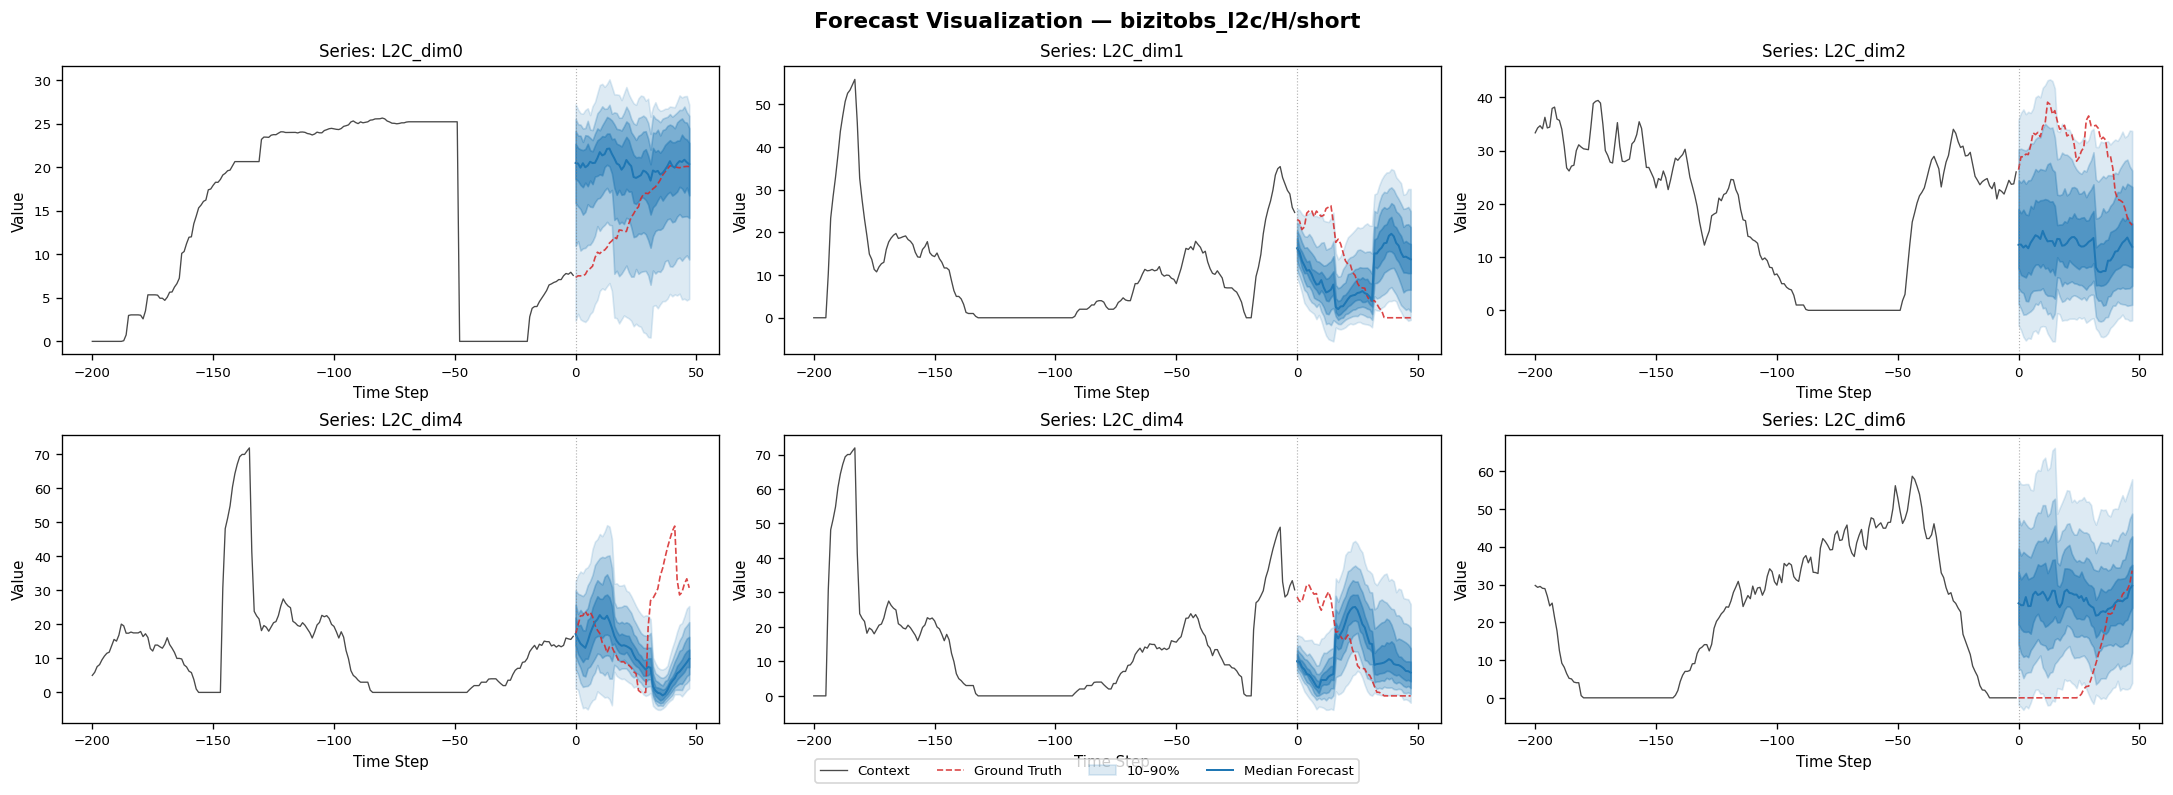

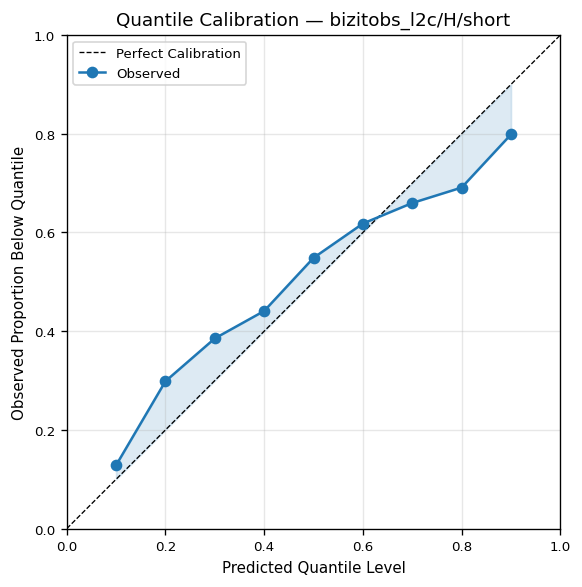

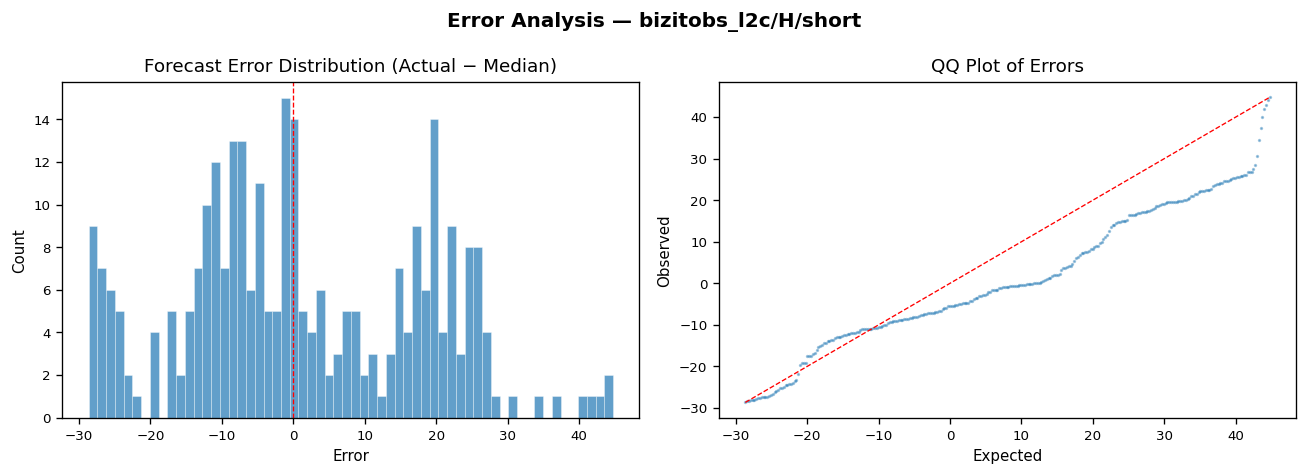


🔍 Visualizing: bizitobs_l2c/H/medium


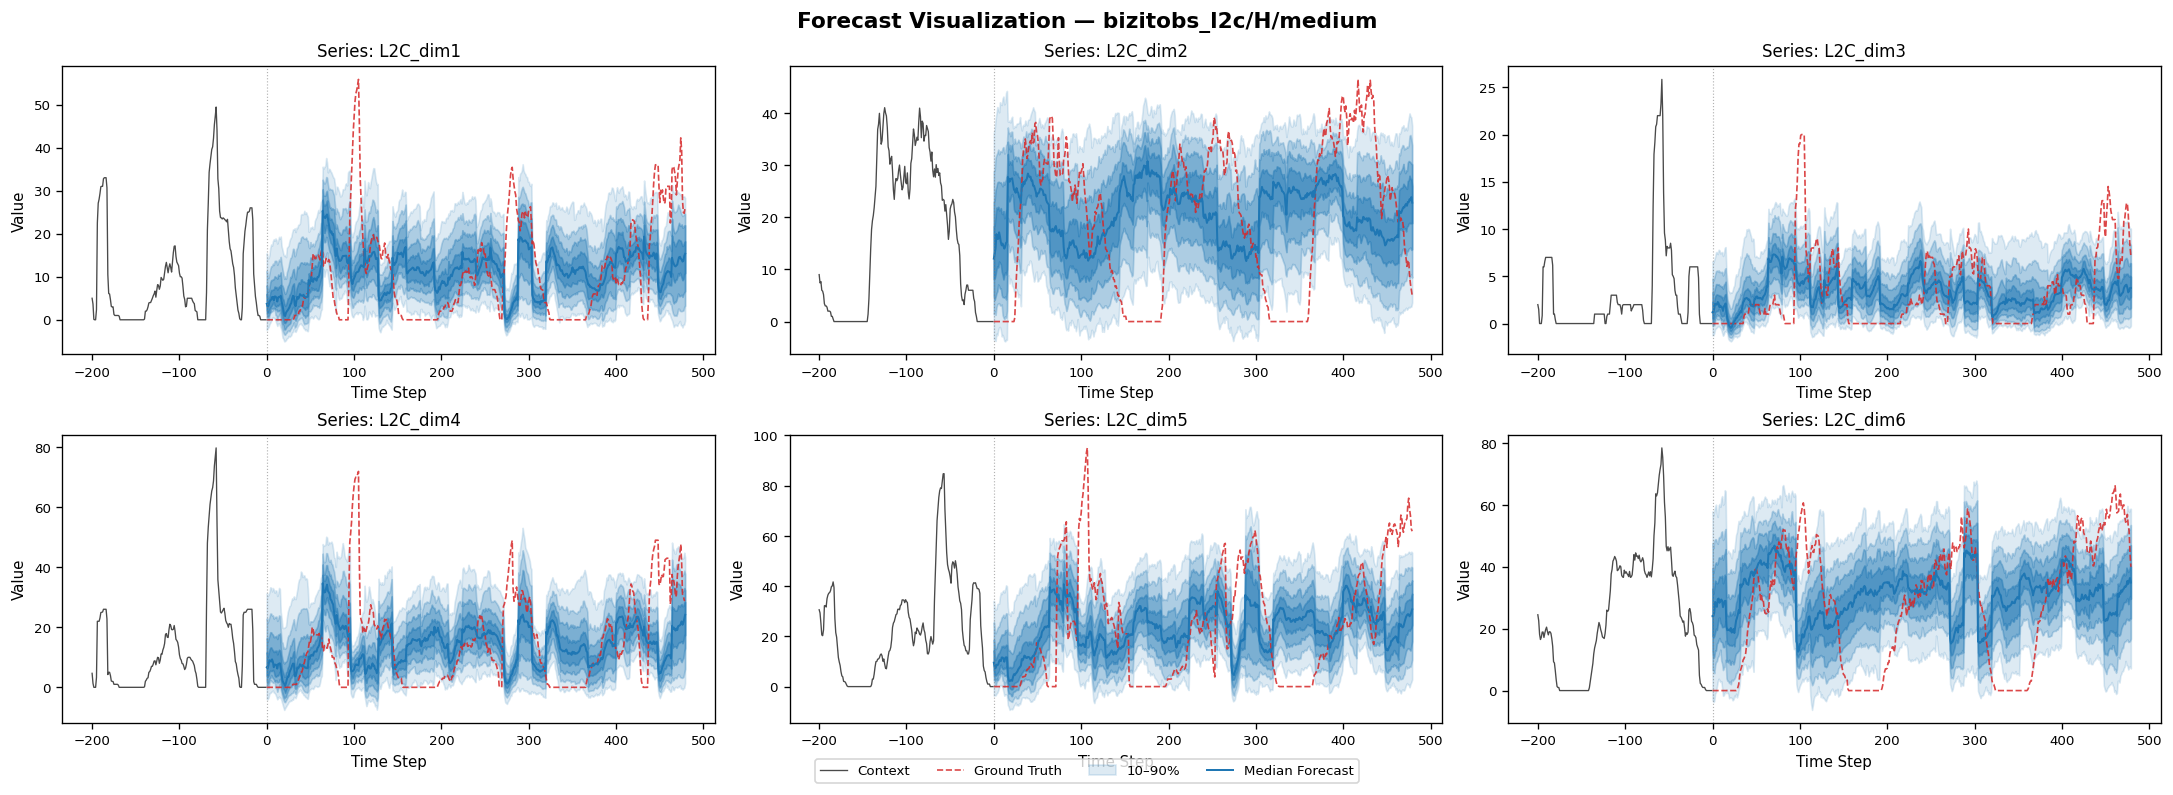

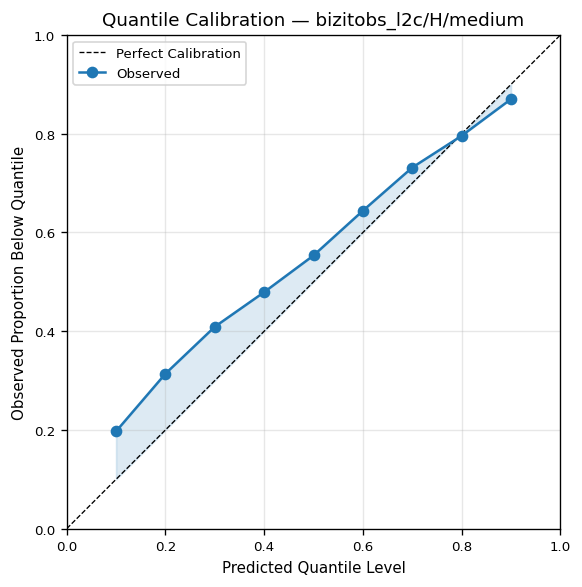

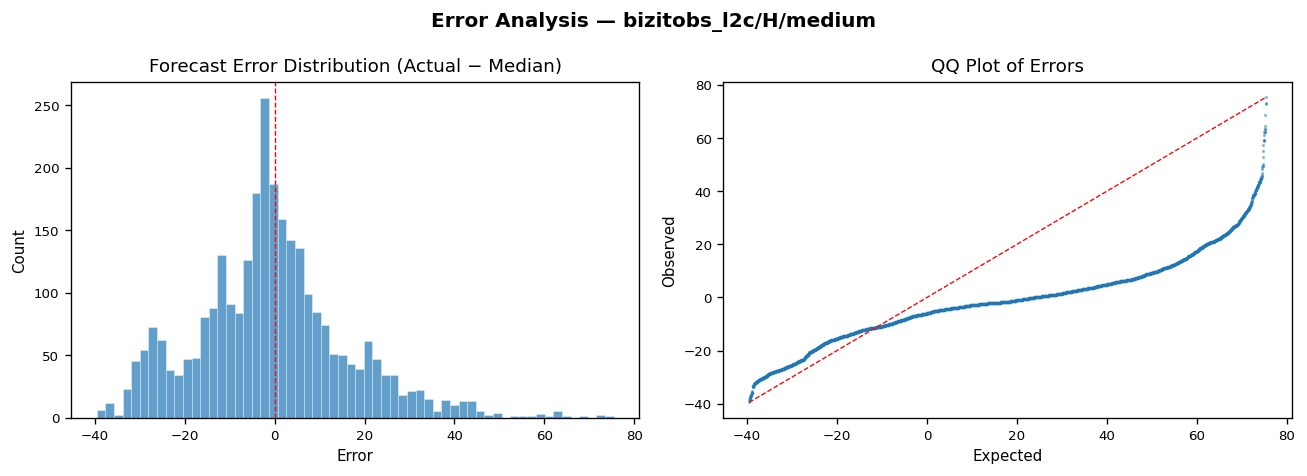


🔍 Visualizing: bizitobs_l2c/H/long


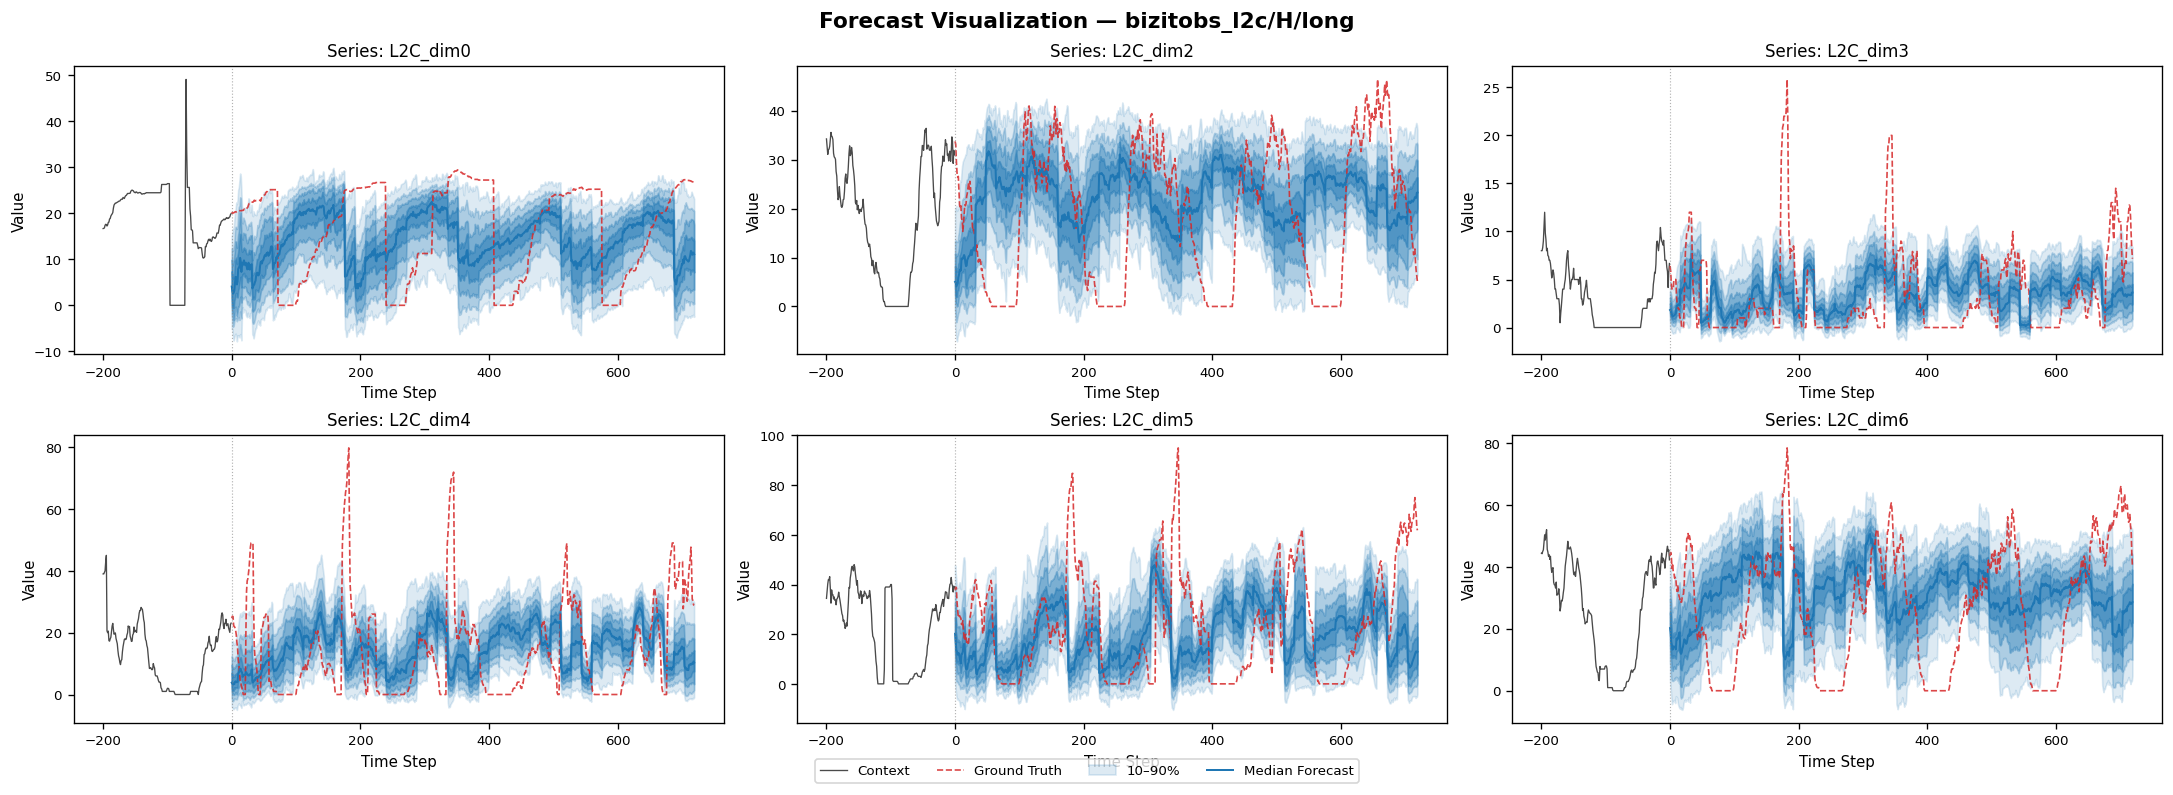

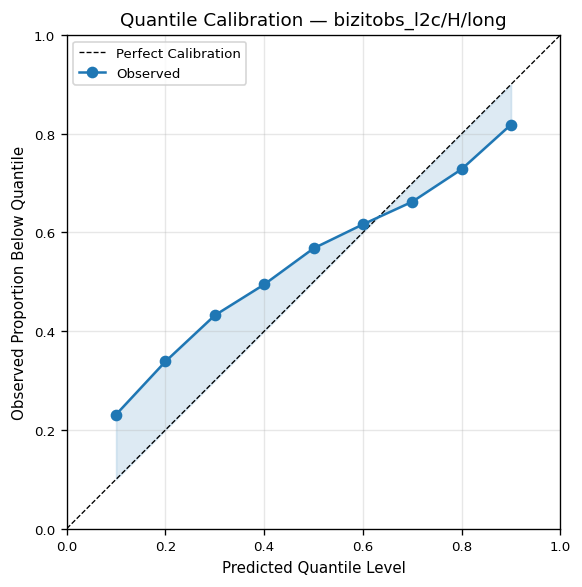

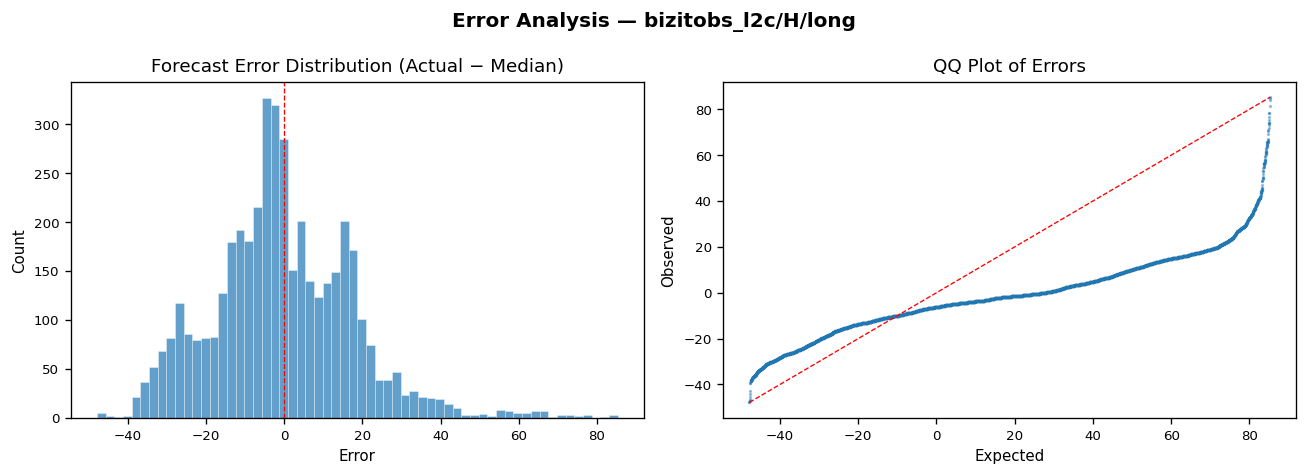


🔍 Visualizing: electricity/H/short


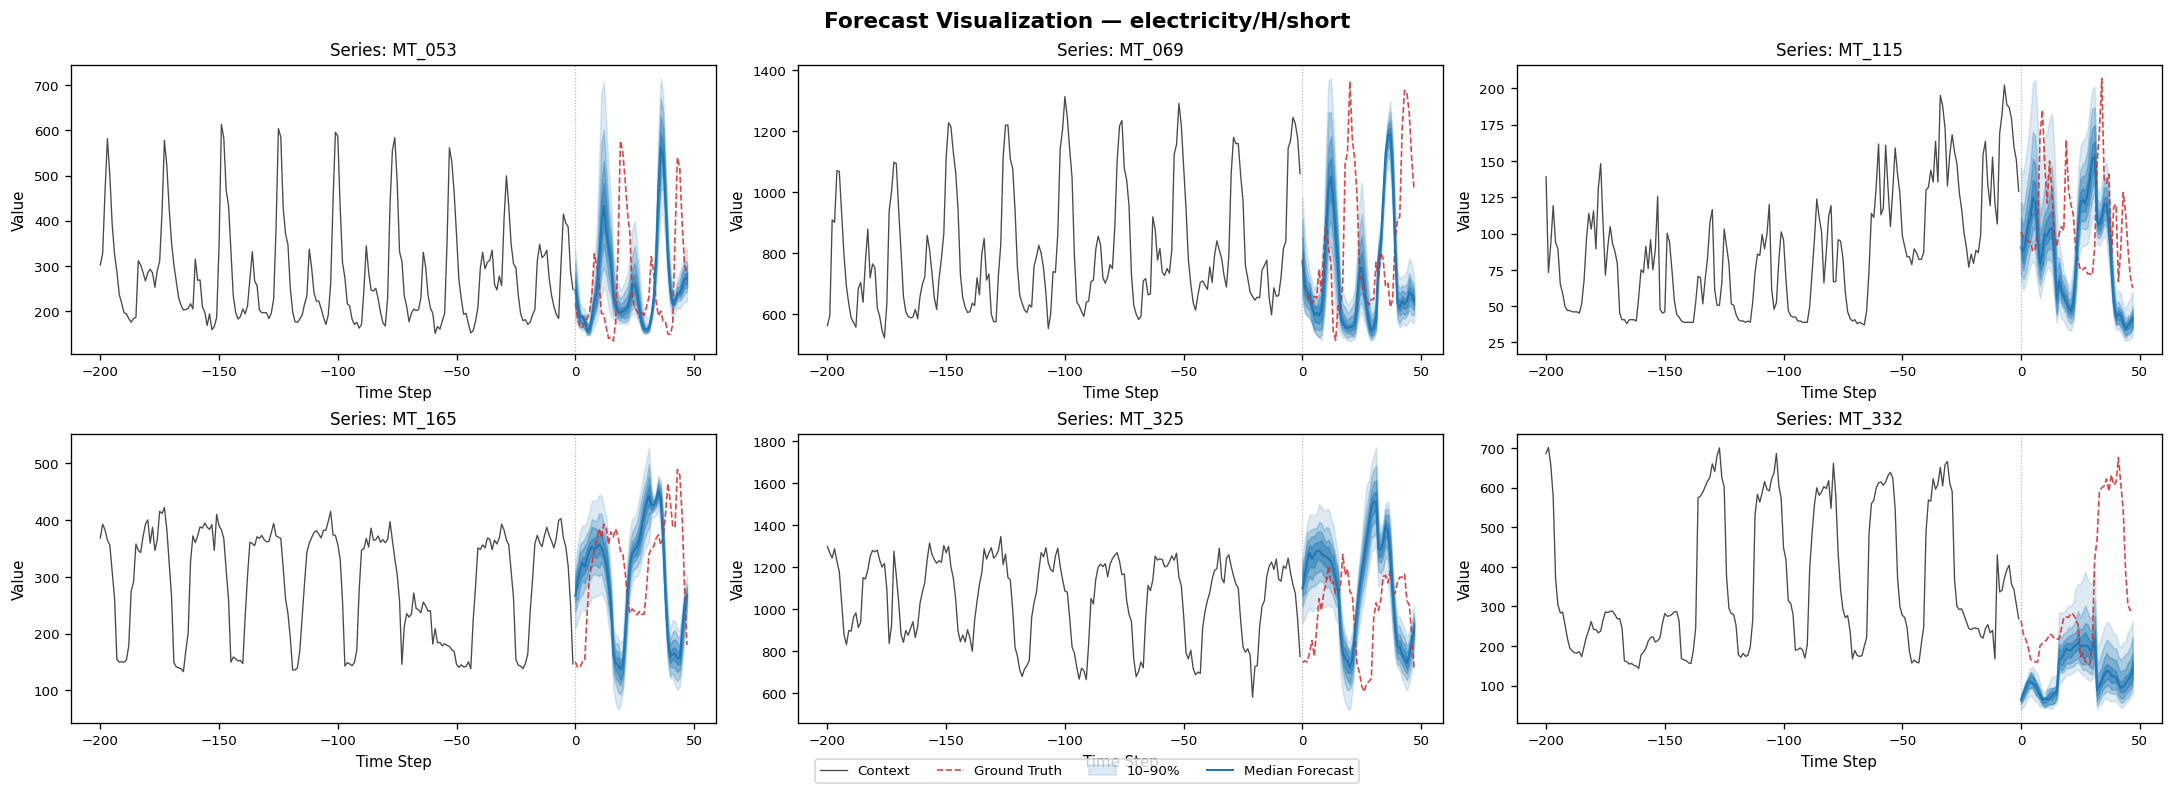

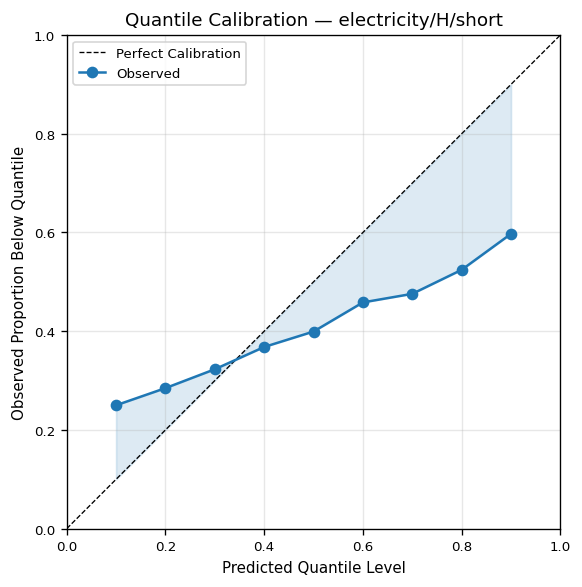

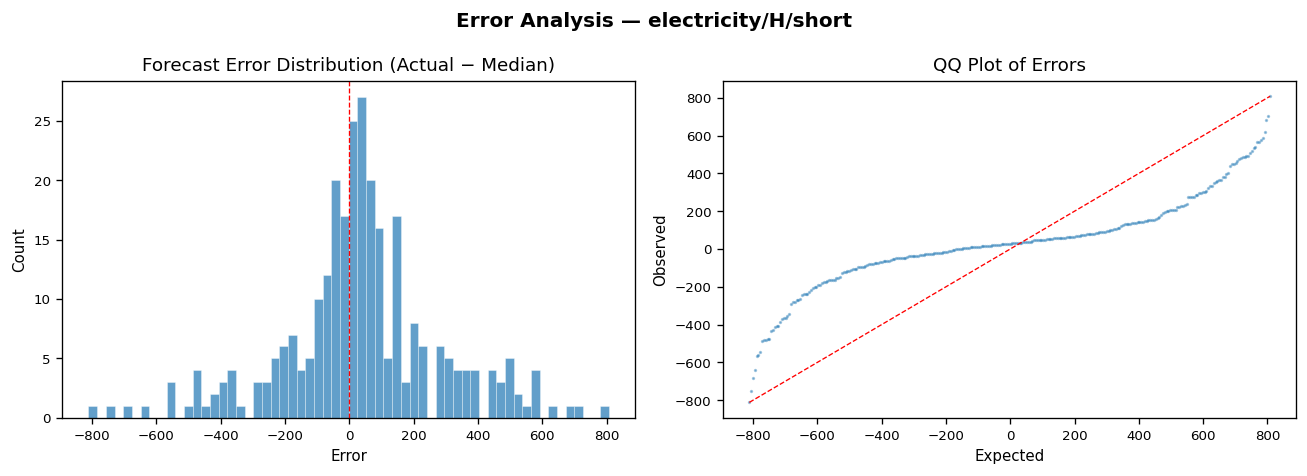

In [9]:
rng = np.random.RandomState(VIZ_SEED)

for ds_name in all_datasets:
    terms = ["short", "medium", "long"]
    for term in terms:
        if term in ("medium", "long") and ds_name not in MED_LONG_DATASETS.split():
            continue

        ds_key, ds_freq, ds_config = resolve_ds_config(ds_name, term)
        print(f"\n🔍 Visualizing: {ds_config}")

        to_univariate = Dataset(name=ds_name, term=term, to_univariate=False).target_dim != 1
        dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)

        # Collect test inputs and labels
        test_inputs = list(dataset.test_data.input)
        test_labels = list(dataset.test_data.label)
        total_series = len(test_inputs)

        # Select random subset of series to visualize
        n_plot = min(NUM_SERIES_TO_PLOT, total_series)
        selected_idx = sorted(rng.choice(total_series, size=n_plot, replace=False))

        selected_inputs = [test_inputs[i] for i in selected_idx]
        selected_labels = [test_labels[i] for i in selected_idx]

        # Build predictor (reuses pre-loaded module)
        predictor = MoiraiQuantilePredictor(
            module=module,
            prediction_length=dataset.prediction_length,
            context_length=CONTEXT_LENGTH,
            target_dim=1,
            past_feat_dynamic_real_dim=dataset.past_feat_dynamic_real_dim,
            device=device,
            batch_size=BATCH_SIZE,
            quantile_levels=QUANTILE_LEVELS,
        )

        # Generate forecasts for selected series
        forecasts = predictor.predict(selected_inputs)

        # Extract context and ground truth arrays
        contexts = []
        ground_truths = []
        for inp, lbl in zip(selected_inputs, selected_labels):
            # Context: the input target (may be 1D or 2D for multivariate)
            ctx = np.asarray(inp["target"])
            if ctx.ndim > 1:
                ctx = ctx[0]  # take first variate for plotting
            contexts.append(ctx)

            # Ground truth: label target
            gt = np.asarray(lbl["target"])
            if gt.ndim > 1:
                gt = gt[0]
            ground_truths.append(gt)

        # --- Fan chart grid ---
        plot_forecast_grid(
            contexts, ground_truths, forecasts, ds_config,
            context_points=CONTEXT_POINTS_TO_SHOW,
            max_plots=NUM_SERIES_TO_PLOT,
        )

        # --- Calibration plot ---
        plot_calibration(
            *compute_calibration(ground_truths, forecasts, QUANTILE_LEVELS),
            dataset_label=ds_config,
        )

        # --- Error distribution ---
        plot_error_distribution(ground_truths, forecasts, ds_config)

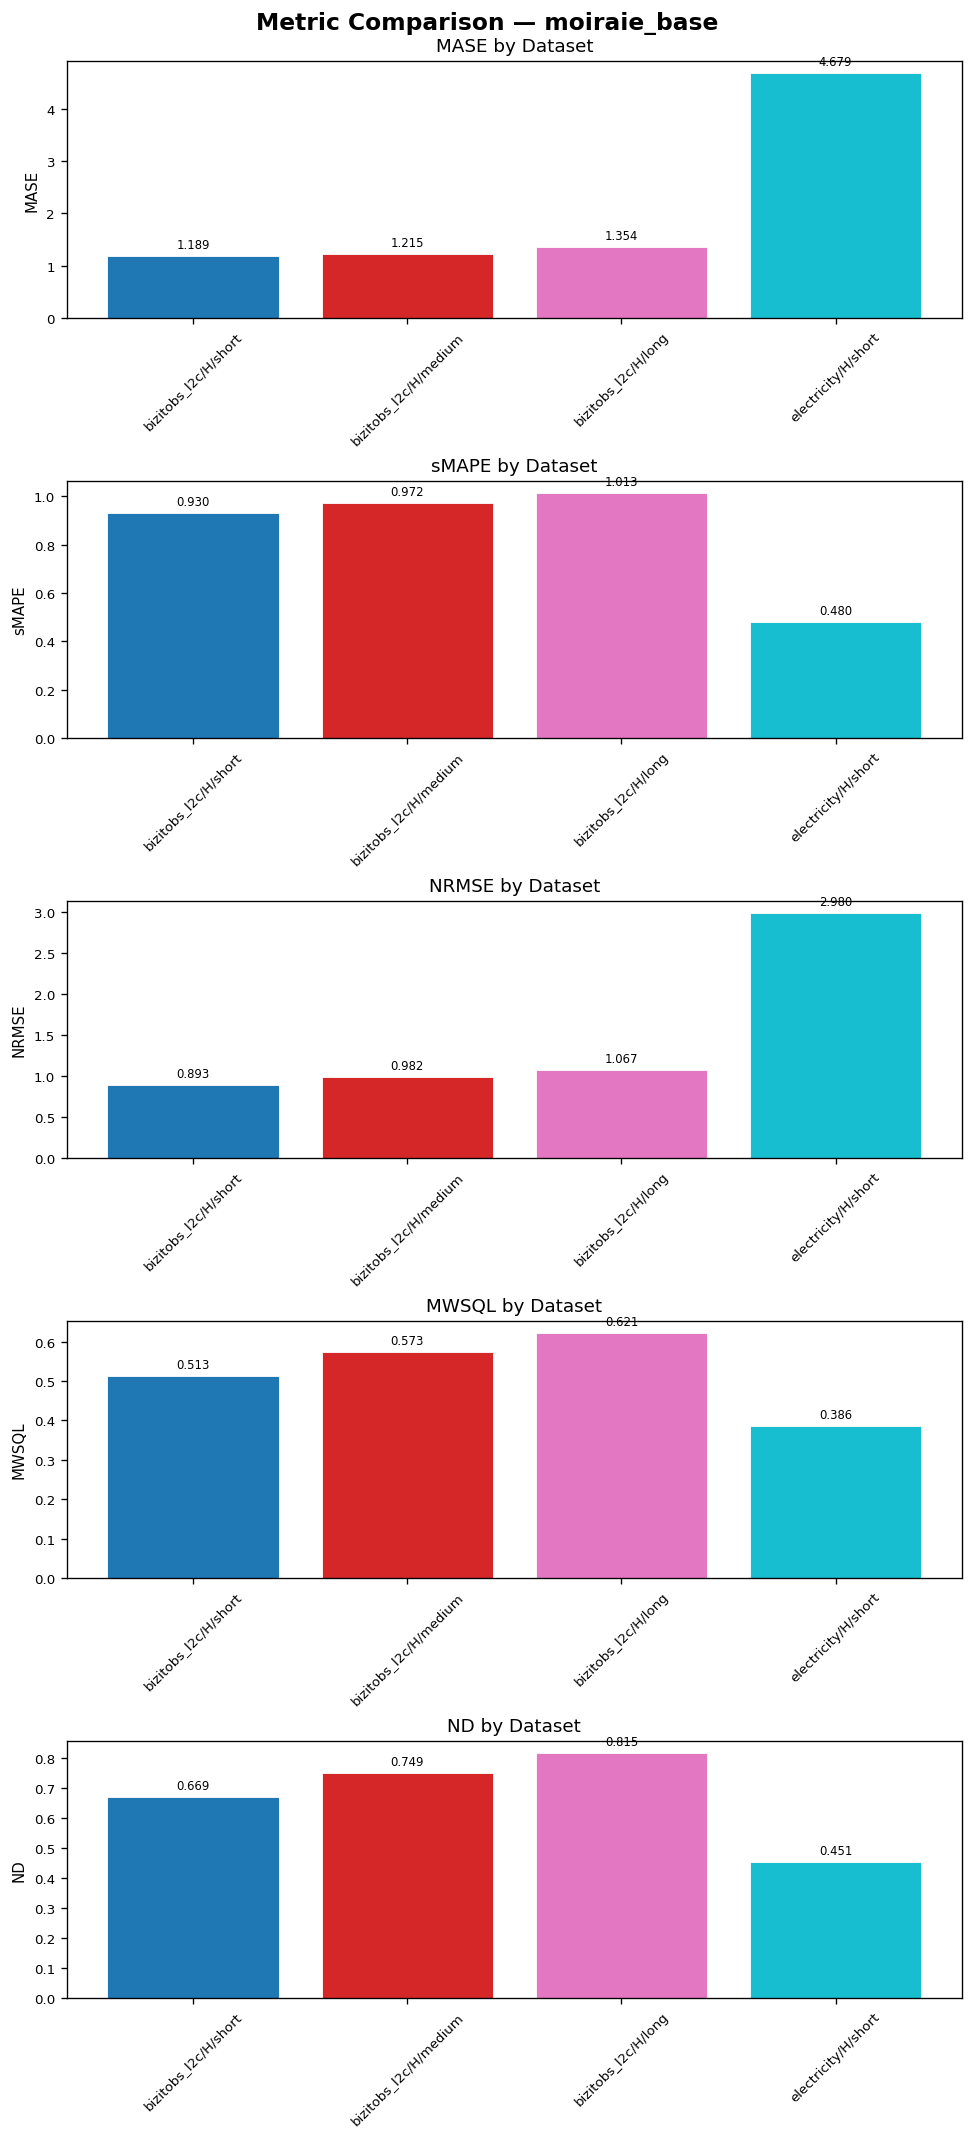

In [10]:
df = pd.read_csv(csv_file_path)

if len(df) == 0:
    print("No results to plot yet. Run the evaluation cell first.")
else:
    # Select key metrics to visualize
    key_metrics = [
        ("eval_metrics/MASE[0.5]", "MASE"),
        ("eval_metrics/sMAPE[0.5]", "sMAPE"),
        ("eval_metrics/NRMSE[mean]", "NRMSE"),
        ("eval_metrics/mean_weighted_sum_quantile_loss", "MWSQL"),
        ("eval_metrics/ND[0.5]", "ND"),
    ]
    
    n_metrics = len(key_metrics)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(max(8, len(df) * 1.2), 3.5 * n_metrics),
                             constrained_layout=True)
    if n_metrics == 1:
        axes = [axes]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    
    for ax, (col, label) in zip(axes, key_metrics):
        if col not in df.columns:
            ax.set_visible(False)
            continue
        bars = ax.bar(df["dataset"], df[col], color=colors, edgecolor="white", linewidth=0.5)
        ax.set_ylabel(label)
        ax.set_title(f"{label} by Dataset", fontsize=11)
        ax.tick_params(axis="x", rotation=45)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if np.isfinite(height):
                ax.annotate(f"{height:.3f}",
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha="center", va="bottom", fontsize=7)
    
    fig.suptitle(f"Metric Comparison — {MODEL_NAME}", fontsize=14, fontweight="bold", y=1.01)
    plt.show()

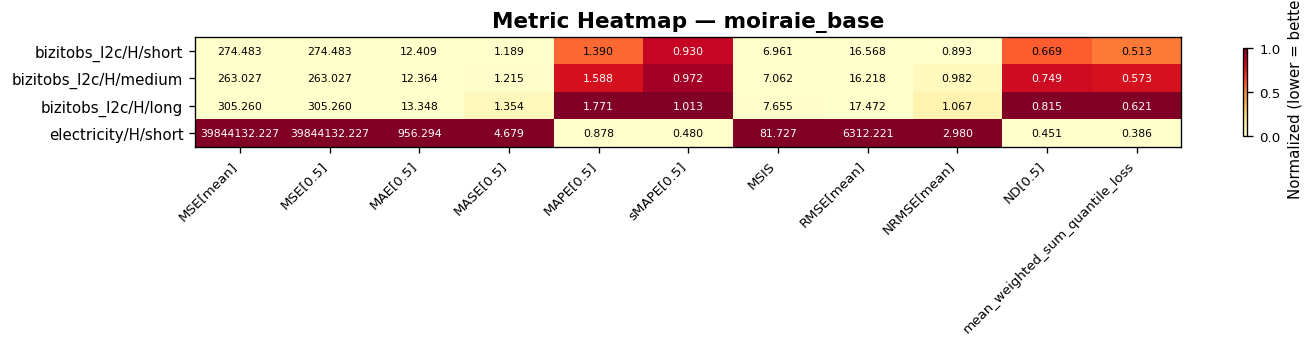

In [11]:
df = pd.read_csv(csv_file_path)

if len(df) > 1:
    # Build a heatmap of normalized metrics across datasets
    metric_cols = [c for c in df.columns if c.startswith("eval_metrics/")]
    df_metrics = df.set_index("dataset")[metric_cols].copy()
    
    # Normalize each metric column to [0, 1] for comparable color scaling
    df_norm = (df_metrics - df_metrics.min()) / (df_metrics.max() - df_metrics.min() + 1e-12)
    
    # Shorten column names for display
    short_names = [c.replace("eval_metrics/", "") for c in df_norm.columns]
    df_norm.columns = short_names
    
    fig, ax = plt.subplots(figsize=(max(10, len(short_names) * 1.1), max(3, len(df_norm) * 0.6)))
    im = ax.imshow(df_norm.values, cmap="YlOrRd", aspect="auto")
    
    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(df_norm)))
    ax.set_yticklabels(df_norm.index, fontsize=9)
    
    # Annotate cells with raw values
    for i in range(len(df_norm)):
        for j in range(len(short_names)):
            raw_val = df_metrics.iloc[i, j]
            ax.text(j, i, f"{raw_val:.3f}", ha="center", va="center", fontsize=6.5,
                   color="white" if df_norm.iloc[i, j] > 0.6 else "black")
    
    plt.colorbar(im, ax=ax, shrink=0.8, label="Normalized (lower = better)")
    ax.set_title(f"Metric Heatmap — {MODEL_NAME}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Heatmap requires results from multiple datasets. Run evaluation on more datasets first.")